In [19]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import legendre, legendre_p
import pysindy as ps

# import modules from parent dir
# from <https://stackoverflow.com/questions/714063/importing-modules-from-parent-folder>
import os
# below no worki, maybe because of ipynb?
# import sys
# import inspect
# currentdir = os.path.dirname(os.path.abspath(inspect.getfile(inspect.currentframe())))
# print(currentdir)
# parentdir = os.path.dirname(currentdir)
# print(parentdir)
# sys.path.insert(0, parentdir)

currentdir = os.getcwd()
if currentdir.split("/")[-1] != 'yukawa-sindy':
    parentdir = os.path.dirname(currentdir)
    os.chdir(parentdir)

import Yukawa_SINDy as ys
import cross_validation as cv
import pickle as pkl
import anisotropic_potential as ap

# import Yukawa scaling constant
with open('scaling_const.float', 'rb') as f:
    SCALING_CONST = pkl.load(f)

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({'figure.figsize': (8,6)})

In [20]:
from importlib import reload
reload(ap)

<module 'anisotropic_potential' from '/Users/zbh0005/Library/CloudStorage/OneDrive-AuburnUniversity/Documents/Code/yukawa-sindy/anisotropic_potential.py'>

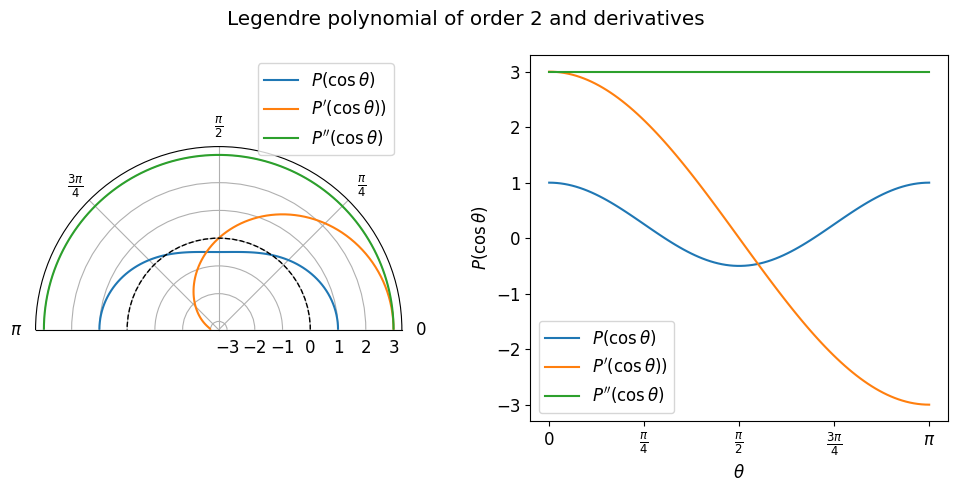

In [21]:
order = 2
theta = np.r_[0:np.pi:100j]
x = np.cos(theta)
y = legendre_p(order, x, diff_n = 2).T

fig, axd = plt.subplot_mosaic("AB", per_subplot_kw={"A": {'projection': 'polar'}},figsize=(10,5))
for key in axd.keys():
    axd[key].plot(theta, y, label = ["$P(\\cos\\theta)$", "$P'(\\cos\\theta))$", "$P''(\\cos\\theta)$"])
    axd[key].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
    axd[key].set_xticklabels(['0', '$\\frac{\\pi}{4}$', '$\\frac{\\pi}{2}$', '$\\frac{3\\pi}{4}$', '$\\pi$'])
    axd[key].legend()

axd['A'].set_thetamax(180)
axd['A'].axhline(c='black', lw=1, ls='--')

axd['B'].set_xlabel('$\\theta$')
axd['B'].set_ylabel('$P(\cos\\theta)$')
# axd['B'].set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
# axd['B'].set_xticklabels(['0', '$\\frac{\\pi}{4}$', '$\\frac{\\pi}{2}$', '$\\frac{3\\pi}{4}$', '$\\pi$'])

fig.suptitle(f"Legendre polynomial of order {order} and derivatives")
fig. tight_layout()

In [22]:
test = legendre_p(order, x, diff_n = 2)
test.shape

(3, 100)

In [23]:
rng = np.random.default_rng(seed=520967)
sim = ap.Anisotropic_simulation(rng=rng)

In [24]:
sim.__dict__

{'_duration': None,
 '_dt': None,
 'is_noisy': False,
 '_noise_level': 0,
 'is_subsampled': False,
 '_sample_frac': 1,
 '_t': None,
 '_t_full': None,
 '_x': None,
 '_x_clean': None,
 '_x_fullnoisydata': None,
 '_x_cart': None,
 '_init_cond': None,
 'rng': Generator(PCG64) at 0x3531A5460}